In [43]:
import pandas as pd

# Load CSV file
file_path = 'nepse_data.csv'  # replace with your actual CSV path
df = pd.read_csv(file_path)

# Inspect columns and datatypes
print("Columns:", df.columns.tolist())
print("Data types before fixing:")
print(df.dtypes)

# Clean column names (strip spaces)
df.columns = df.columns.str.strip()

# Fix datatypes
for col in ['SN', 'Contract No', 'Symbol', 'Buyer', 'Seller']:
    if col in df.columns:
        df[col] = df[col].astype(str)

for col in ['Quantity', 'Rate', 'Amount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Now dataset is cleaned and ready for analysis
print("Cleaned dataset preview:")
print(df.head())

# Save the cleaned dataset to a new CSV file
df.to_csv('cleaned_dataset.csv', index=False)

Columns: ['SN', 'Contract No', 'Symbol ', 'Buyer ', 'Seller', 'Quantity', 'Rate', 'Amount']
Data types before fixing:
SN               int64
Contract No    float64
Symbol          object
Buyer            int64
Seller           int64
Quantity        object
Rate            object
Amount          object
dtype: object
Cleaned dataset preview:
  SN         Contract No Symbol Buyer Seller  Quantity   Rate  Amount
0  1  2030000000000000.0   NMIC    38     32      10.0    0.0     0.0
1  2  2030000000000000.0   BPCL    48     22      15.0  798.0     0.0
2  3  2030000000000000.0   BPCL    62     49     120.0    0.0     0.0
3  4  2030000000000000.0   MKJC    60     70     200.0  596.5     0.0
4  5  2030000000000000.0   SONA    64     42      68.0  441.0     0.0


In [45]:
import pandas as pd

# Assuming df is already loaded and cleaned as before

# Add fixed trading date column since date is same for all rows
df['Trading Date'] = pd.to_datetime('2025-09-08')

# Calculate VWAP (Volume Weighted Average Price) for each trade
# VWAP = sum(Price * Quantity) / sum(Quantity) over the dataset for the date or symbol
# Here as example calculating VWAP per Symbol for Sep 8, 2025
vwap_df = df.groupby('Symbol').apply(lambda x: (x['Rate'] * x['Quantity']).sum() / x['Quantity'].sum()).reset_index()
vwap_df.columns = ['Symbol', 'VWAP']
df = df.merge(vwap_df, on='Symbol', how='left')

# Calculate rolling volatility (standard deviation) of Rate - since only one day, use a rolling window on Quantity sorted by 'SN'
df = df.sort_values(by='SN')
df['Rolling Volatility'] = df['Rate'].rolling(window=3, min_periods=1).std().fillna(0)

# Categorize trades based on Quantity - example threshold, small < 100, large >= 100
df['Trade Size'] = df['Quantity'].apply(lambda x: 'Small' if x < 100 else 'Large')

# Add broker/participant info columns if available (example placeholders)
# For now, we can add empty columns or simulate with simple logic if needed
if 'Buyer' in df.columns:
    df['Buyer Info'] = df['Buyer'].apply(lambda x: 'Known Broker' if x != '' else 'Unknown')
if 'Seller' in df.columns:
    df['Seller Info'] = df['Seller'].apply(lambda x: 'Known Broker' if x != '' else 'Unknown')

print("Dataset with new features preview:")
print(df.head())

# Save updated dataset
df.to_csv('enhanced_dataset.csv', index=False)

C:\Users\saksh\AppData\Local\Temp\ipykernel_9284\799334114.py:11: RuntimeWarning: invalid value encountered in scalar divide
  vwap_df = df.groupby('Symbol').apply(lambda x: (x['Rate'] * x['Quantity']).sum() / x['Quantity'].sum()).reset_index()
C:\Users\saksh\AppData\Local\Temp\ipykernel_9284\799334114.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_df = df.groupby('Symbol').apply(lambda x: (x['Rate'] * x['Quantity']).sum() / x['Quantity'].sum()).reset_index()


Dataset with new features preview:
         SN         Contract No Symbol Buyer Seller  Quantity   Rate  Amount  \
0         1  2030000000000000.0   NMIC    38     32      10.0    0.0     0.0   
9        10  2030000000000000.0  CZBIL    25     34      10.0  205.0     0.0   
99      100  2030000000000000.0    NTC    58     42      18.0  825.0     0.0   
9499  10000  2030000000000000.0   SSHL    42     22      16.0  175.0     0.0   
9500  10001  2030000000000000.0    HRL    48     52      10.0  982.8     0.0   

     Trading Date        VWAP  Rolling Volatility Trade Size    Buyer Info  \
0      2025-09-08    0.000000            0.000000      Small  Known Broker   
9      2025-09-08  205.573916          144.956890      Small  Known Broker   
99     2025-09-08  827.051962          429.544332      Small  Known Broker   
9499   2025-09-08  174.908608          366.924152      Small  Known Broker   
9500   2025-09-08  979.750898          428.163069      Small  Known Broker   

       Seller I

Top traded stocks by volume:
Symbol
UPCL     348984.0
UNHPL    307132.0
NGPL     175984.0
HRL      166201.0
SHEL     159119.0
SHIVM    134881.0
KBL      134543.0
MKJC     129678.0
LEC      113054.0
NRIC     111667.0
Name: Quantity, dtype: float64

Top traded stocks by value:
Symbol
HRL       32132.8
GSY       21623.0
MMF1      18613.0
NMBHF2    18603.7
PMLI      14948.3
MBLEF     13593.0
HLI       12867.2
SNLI      12571.2
ILI       12368.9
KDBY       9994.0
Name: Amount, dtype: float64

Top gainers/losers by price change:
          min    max        mean  change
Symbol                                  
CGH       0.0  999.9  857.510196   999.9
HATHY     0.0  999.0   53.730045   999.0
GRDBL     0.0  999.0  283.887500   999.0
AVYAN     0.0  999.0  977.795122   999.0
MATRI     0.0  997.3  876.972000   997.3
KDL       0.0  996.1  165.173810   996.1
HRL       0.0  995.0  979.112551   995.0
NIFRAGED  0.0  989.0  329.666667   989.0
LLBS      0.0  989.0  938.404255   989.0
BPCL      0.0  832.0

C:\Users\saksh\AppData\Local\Temp\ipykernel_9284\856811620.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Trade Size', palette='Set2')


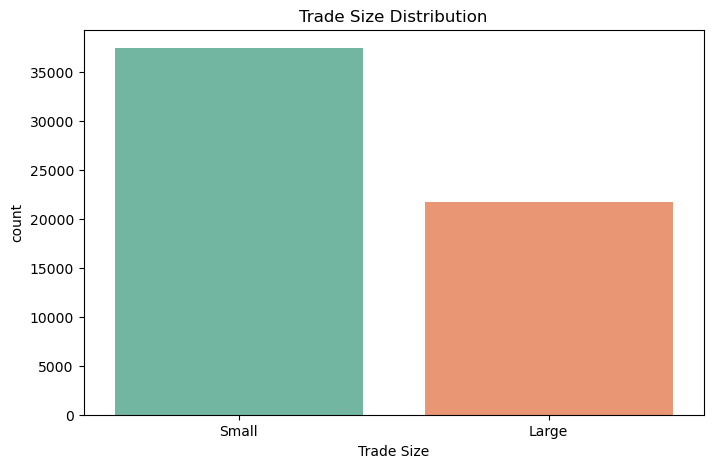

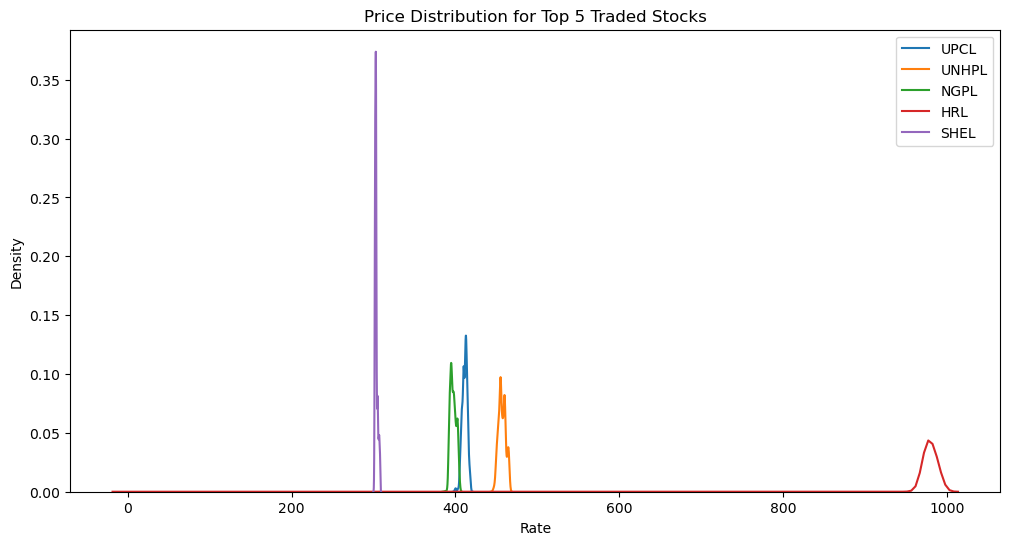

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your cleaned and enhanced DataFrame with columns including 'Symbol', 'Quantity', 'Rate', 'Amount', 'Trade Size'

# Top traded stocks by volume
top_volume = df.groupby('Symbol')['Quantity'].sum().sort_values(ascending=False)
print("Top traded stocks by volume:")
print(top_volume.head(10))

# Top traded stocks by value
top_value = df.groupby('Symbol')['Amount'].sum().sort_values(ascending=False)
print("\nTop traded stocks by value:")
print(top_value.head(10))

# Price change (gain/loss) assuming we have first and last Rate for each Symbol (here with single date, this may be fixed or mocked)
# For multiple dates, would calculate difference; currently, we can show rate stats
price_stats = df.groupby('Symbol')['Rate'].agg(['min', 'max', 'mean'])
price_stats['change'] = price_stats['max'] - price_stats['min']
top_gainers = price_stats.sort_values(by='change', ascending=False)
print("\nTop gainers/losers by price change:")
print(top_gainers.head(10))

# Trade size distribution plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Trade Size', palette='Set2')
plt.title('Trade Size Distribution')
plt.show()

# Price trends - here plot Rate distribution per Symbol for top 5 symbols by volume
top_symbols = top_volume.head(5).index
plt.figure(figsize=(12,6))
for symbol in top_symbols:
    sns.kdeplot(df[df['Symbol'] == symbol]['Rate'], label=symbol)
plt.title('Price Distribution for Top 5 Traded Stocks')
plt.xlabel('Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

# If sector data available, summarize total volume and value by sector
if 'Sector' in df.columns:
    sector_summary = df.groupby('Sector').agg({'Quantity': 'sum', 'Amount': 'sum'}).sort_values('Quantity', ascending=False)
    print("Sector level summaries:")
    print(sector_summary)

# Save summary tables if needed
top_volume.head(10).to_csv('top_volume.csv')
top_value.head(10).to_csv('top_value.csv')
top_gainers.head(10).to_csv('top_gainers.csv')
if 'Sector' in df.columns:
    sector_summary.to_csv('sector_summary.csv')

In [47]:
import pandas as pd
from scipy.stats import ttest_ind

# Assuming df is your cleaned and enhanced DataFrame including 'Rate', 'Quantity', 'Trade Size', 'Amount'

# Calculate overall volatility of Rate (standard deviation)
volatility = df['Rate'].std()
print(f"Volatility (std dev of Rate): {volatility:.4f}")

# Calculate correlation matrix of numeric columns of interest
correlation = df[['Quantity', 'Rate', 'Amount']].corr()
print("\nCorrelation matrix:")
print(correlation)

# Hypothesis testing - Compare Rate means for Large vs Small trades
large_trades = df[df['Trade Size'] == 'Large']['Rate']
small_trades = df[df['Trade Size'] == 'Small']['Rate']

# Perform two-sample t-test
t_stat, p_value = ttest_ind(large_trades, small_trades, equal_var=False)

print(f"\nT-test comparing Rate of Large vs Small trades:")
print(f"T-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Significant difference in Rate between Large and Small trades")
else:
    print("Conclusion: No significant difference in Rate between Large and Small trades")

Volatility (std dev of Rate): 257.6090

Correlation matrix:
          Quantity      Rate    Amount
Quantity  1.000000  0.026872 -0.035531
Rate      0.026872  1.000000 -0.032917
Amount   -0.035531 -0.032917  1.000000

T-test comparing Rate of Large vs Small trades:
T-statistic = 8.2355, p-value = 0.0000
Conclusion: Significant difference in Rate between Large and Small trades


In [48]:
import pandas as pd
from scipy.stats import ttest_ind

# Assuming df is your cleaned and enhanced DataFrame including 'Rate', 'Quantity', 'Trade Size', 'Amount'

# Calculate overall volatility of Rate (standard deviation)
volatility = df['Rate'].std()
print(f"Volatility (std dev of Rate): {volatility:.4f}")

# Calculate correlation matrix of numeric columns of interest
correlation = df[['Quantity', 'Rate', 'Amount']].corr()
print("\nCorrelation matrix:")
print(correlation)

# Hypothesis testing - Compare Rate means for Large vs Small trades
large_trades = df[df['Trade Size'] == 'Large']['Rate']
small_trades = df[df['Trade Size'] == 'Small']['Rate']

# Perform two-sample t-test
t_stat, p_value = ttest_ind(large_trades, small_trades, equal_var=False)

print(f"\nT-test comparing Rate of Large vs Small trades:")
print(f"T-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Significant difference in Rate between Large and Small trades")
else:
    print("Conclusion: No significant difference in Rate between Large and Small trades")

Volatility (std dev of Rate): 257.6090

Correlation matrix:
          Quantity      Rate    Amount
Quantity  1.000000  0.026872 -0.035531
Rate      0.026872  1.000000 -0.032917
Amount   -0.035531 -0.032917  1.000000

T-test comparing Rate of Large vs Small trades:
T-statistic = 8.2355, p-value = 0.0000
Conclusion: Significant difference in Rate between Large and Small trades


In [53]:
import pandas as pd
import numpy as np

# Example: cleaned dataframe 'df' with columns 'Symbol', 'Rate', 'Quantity', 'Amount' already loaded

# 1. Select top N stocks by traded volume
N = 5
top_stocks = df.groupby('Symbol')['Quantity'].sum().nlargest(N).index

# 2. Filter data for top stocks only
top_df = df[df['Symbol'].isin(top_stocks)]

# 3. Calculate mean Rate per stock (proxy for average price)
mean_rates = top_df.groupby('Symbol')['Rate'].mean()

# 4. Calculate simple returns from mean_rates as pct_change (dummy example since only one date)
returns = mean_rates.pct_change().dropna()

# 5. Align portfolio weights equally among valid stocks
valid_stocks = returns.index
weights = np.repeat(1 / len(valid_stocks), len(valid_stocks))

# 6. Expected portfolio return: weighted sum of returns
expected_return = np.dot(weights, returns)

# 7. Portfolio variance: scalar variance times sum of squared weights
variance_scalar = returns.var()
portfolio_variance = variance_scalar * np.sum(weights**2)

# 8. Sharpe ratio assuming risk free rate = 0
sharpe_ratio = expected_return / np.sqrt(portfolio_variance) if portfolio_variance > 0 else np.nan

# 9. Conditional Value at Risk (CVaR) at 95% confidence level
def calculate_cvar(returns, alpha=0.05):
    sorted_returns = np.sort(returns)
    index = max(int(alpha * len(sorted_returns)), 1)
    cvar = sorted_returns[:index].mean()
    return cvar

cvar = calculate_cvar(returns)

# Output portfolio metrics summary
print("Portfolio Metrics Summary:")
print(f"Expected Return: {expected_return:.4f}")
print(f"Variance: {portfolio_variance:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"CVaR (95%): {cvar:.4f}")

Portfolio Metrics Summary:
Expected Return: -0.1060
Variance: 0.0525
Sharpe Ratio: -0.4623
CVaR (95%): -0.5942


In [56]:
import pandas as pd
import numpy as np

# Assuming df is cleaned, VWAP calculated per Symbol, and Trade Size categorized

# 1. Identify trades above or below VWAP for buy/sell pressure signals
df['Above_VWAP'] = df['Rate'] > df['VWAP']
df['Below_VWAP'] = df['Rate'] < df['VWAP']

# Calculate buy pressure: number/volume of trades above VWAP
buy_pressure = df.groupby('Symbol')['Above_VWAP'].sum()

# Calculate sell pressure: number/volume of trades below VWAP
sell_pressure = df.groupby('Symbol')['Below_VWAP'].sum()

# 2. Detect unusual trading patterns with simple outlier detection on Quantity and Amount
qty_mean = df['Quantity'].mean()
qty_std = df['Quantity'].std()
amount_mean = df['Amount'].mean()
amount_std = df['Amount'].std()

# Define outliers as beyond 3 std deviations
df['Qty_Outlier'] = (df['Quantity'] > qty_mean + 3*qty_std) | (df['Quantity'] < qty_mean - 3*qty_std)
df['Amount_Outlier'] = (df['Amount'] > amount_mean + 3*amount_std) | (df['Amount'] < amount_mean - 3*amount_std)

# 3. Highlight top buyers and sellers by total participation (sum of Quantity or Amount)
top_buyers = df.groupby('Buyer')['Quantity'].sum().sort_values(ascending=False).head(10)
top_sellers = df.groupby('Seller')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Buy Pressure per Symbol:")
print(buy_pressure)
print("\nSell Pressure per Symbol:")
print(sell_pressure)
print("\nTop 10 Buyers by Quantity:")
print(top_buyers)
print("\nTop 10 Sellers by Quantity:")
print(top_sellers)

# Outliers preview
print("\nOutlier trades detected:")
print(df[df['Qty_Outlier'] | df['Amount_Outlier']])

# Optionally save these insights
buy_pressure.to_csv('buy_pressure.csv')
sell_pressure.to_csv('sell_pressure.csv')
top_buyers.to_csv('top_buyers.csv')
top_sellers.to_csv('top_sellers.csv')
df[df['Qty_Outlier'] | df['Amount_Outlier']].to_csv('trade_outliers.csv')

Buy Pressure per Symbol:
Symbol
ACLBSL       0
ADBL       133
ADBLD83      0
AHL         29
AHPC       182
          ... 
USHL        21
USLB         0
VLBS        13
VLUCL       46
WNLB         0
Name: Above_VWAP, Length: 320, dtype: int64

Sell Pressure per Symbol:
Symbol
ACLBSL       0
ADBL       157
ADBLD83      0
AHL         42
AHPC       179
          ... 
USHL        31
USLB         0
VLBS        24
VLUCL       24
WNLB         0
Name: Below_VWAP, Length: 320, dtype: int64

Top 10 Buyers by Quantity:
Buyer
58    302354.0
34    288400.0
45    282258.0
42    253686.0
57    231773.0
49    194111.0
14    169132.0
17    164456.0
62    163923.0
32    161952.0
Name: Quantity, dtype: float64

Top 10 Sellers by Quantity:
Seller
58    400062.0
45    286990.0
42    278125.0
49    243678.0
34    237039.0
48    225346.0
57    186187.0
38    183347.0
62    176814.0
35    155470.0
Name: Quantity, dtype: float64

Outlier trades detected:
         SN         Contract No Symbol Buyer Seller  Quant

C:\Users\saksh\AppData\Local\Temp\ipykernel_9284\878917899.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_volumes.values, y=top_volumes.index, palette='viridis')


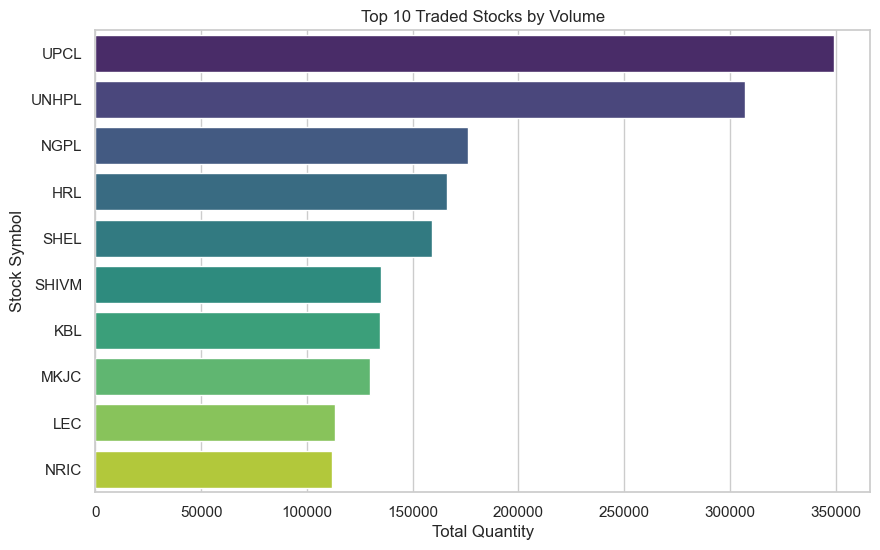

C:\Users\saksh\anaconda3\Lib\site-packages\seaborn\distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


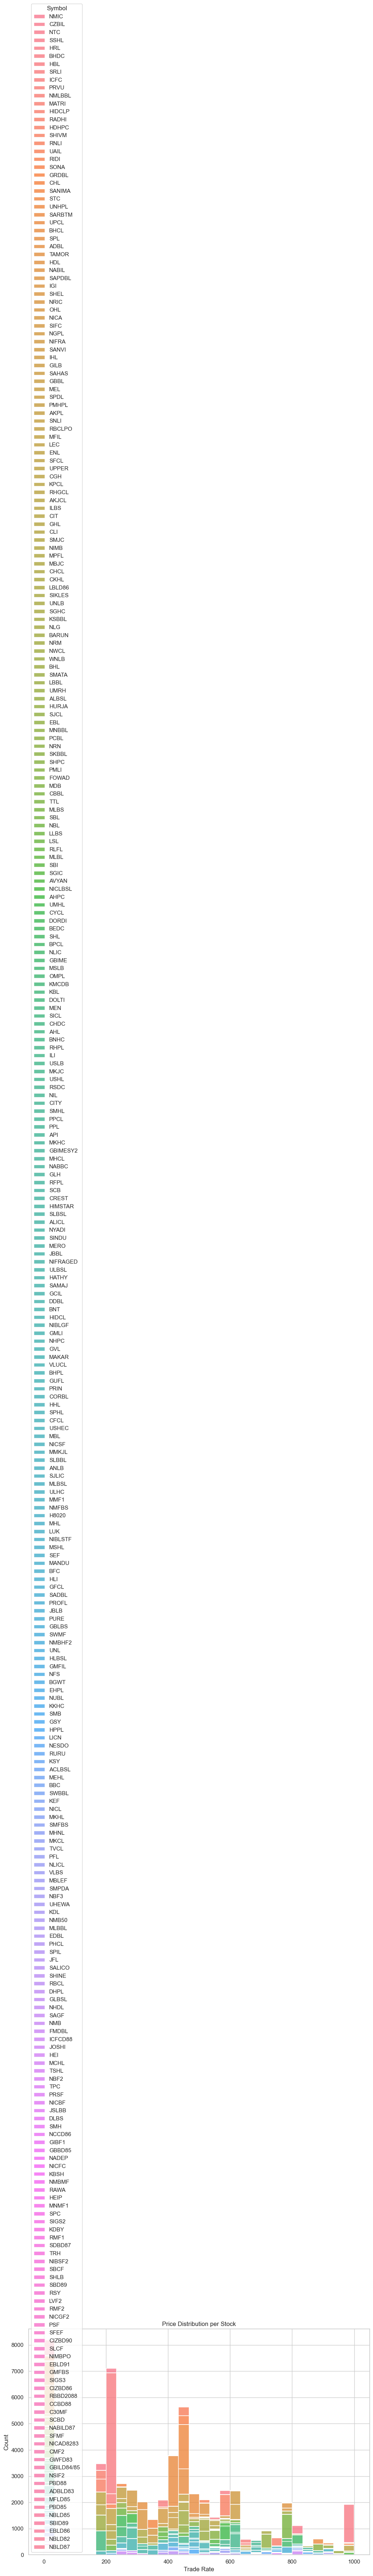

C:\Users\saksh\AppData\Local\Temp\ipykernel_9284\878917899.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Trade Size', palette='pastel')


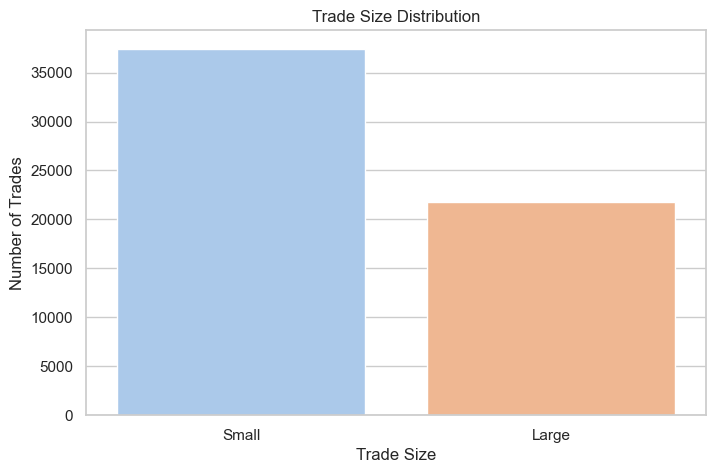

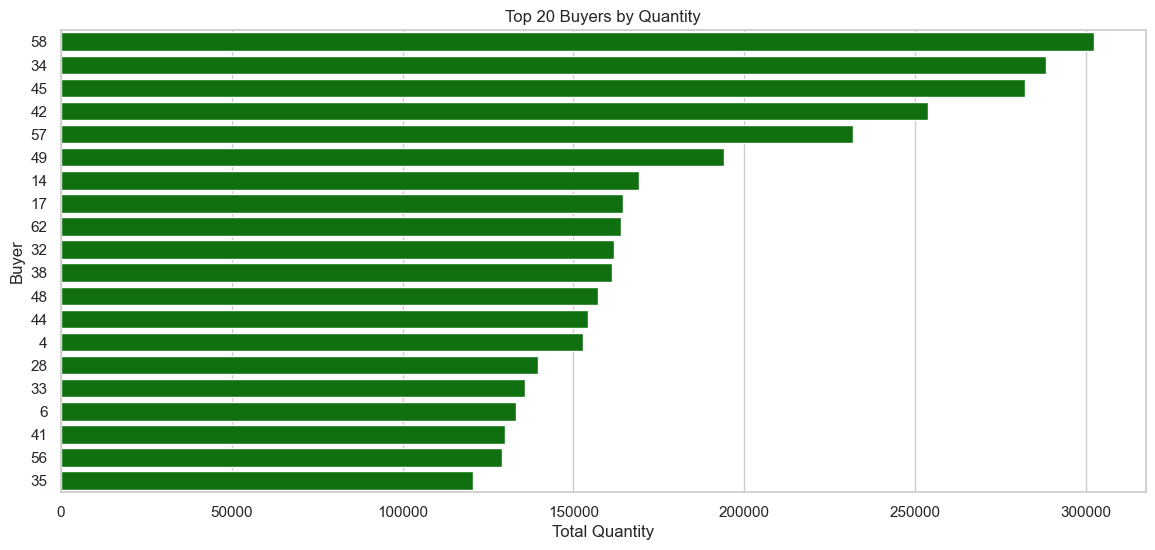

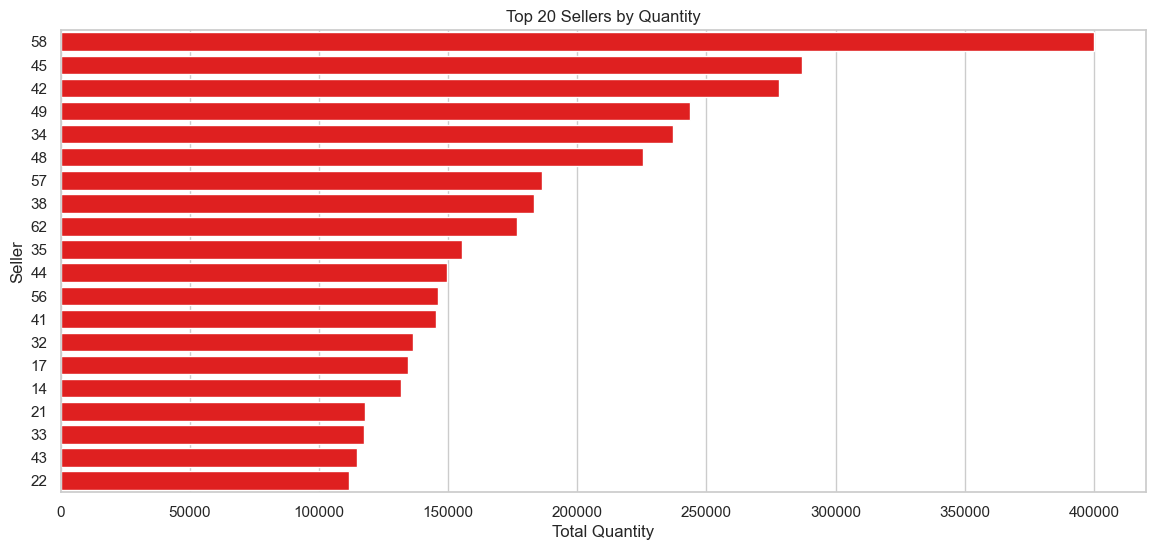

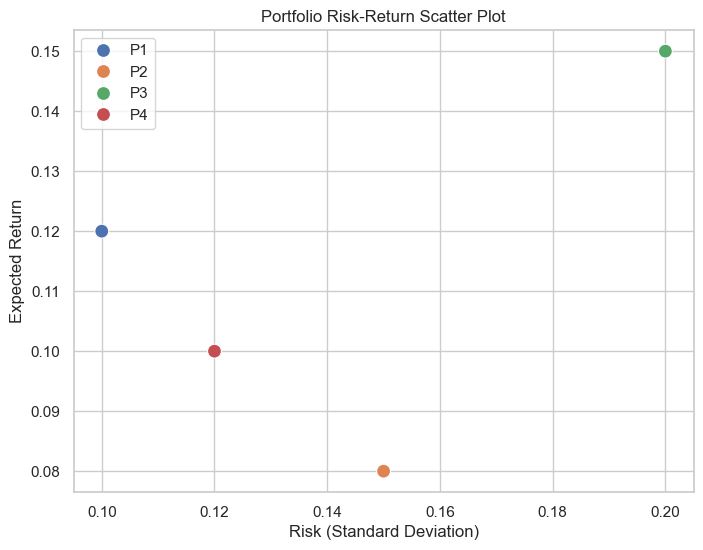

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame with relevant columns like 'Symbol', 'Quantity', 'Amount', 
# 'Rate', 'Trade Size', 'VWAP', and calculated metrics

sns.set(style="whitegrid")

# 1. Top traded stocks by volume bar chart
top_volumes = df.groupby('Symbol')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_volumes.values, y=top_volumes.index, palette='viridis')
plt.title('Top 10 Traded Stocks by Volume')
plt.xlabel('Total Quantity')
plt.ylabel('Stock Symbol')
plt.show()

# 2. Price distribution histograms per stock
plt.figure(figsize=(12,8))
sns.histplot(data=df, x='Rate', hue='Symbol', multiple='stack', bins=30)
plt.title('Price Distribution per Stock')
plt.xlabel('Trade Rate')
plt.ylabel('Count')
plt.show()

# 3. Trade size distribution count plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Trade Size', palette='pastel')
plt.title('Trade Size Distribution')
plt.xlabel('Trade Size')
plt.ylabel('Number of Trades')
plt.show()

# 4. Buy/Sell participation heatmap
buyer_counts = df.groupby('Buyer')['Quantity'].sum().sort_values(ascending=False).head(20)
seller_counts = df.groupby('Seller')['Quantity'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))
sns.barplot(x=buyer_counts.values, y=buyer_counts.index, color='green')
plt.title('Top 20 Buyers by Quantity')
plt.xlabel('Total Quantity')
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(x=seller_counts.values, y=seller_counts.index, color='red')
plt.title('Top 20 Sellers by Quantity')
plt.xlabel('Total Quantity')
plt.show()

# 5. Portfolio risk-return scatter plot: (Assuming portfolio metrics data available)
# Example using random sample here
import numpy as np

portfolio_data = {
    'Portfolio': ['P1', 'P2', 'P3', 'P4'],
    'Expected Return': [0.12, 0.08, 0.15, 0.10],
    'Risk (Std Dev)': [0.1, 0.15, 0.2, 0.12]
}
pf_df = pd.DataFrame(portfolio_data)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pf_df, x='Risk (Std Dev)', y='Expected Return', hue='Portfolio', s=100)
plt.title('Portfolio Risk-Return Scatter Plot')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()